# Baseline model 

🎯 **Goal**: Baseline Model

Train and evaluate a first baseline model to predict board game ratings from the cleaned feature set prepared in Notebook 3 (Feature Preparation).

Key steps include:

- Load cleaned feature matrix (`X`) and target (`y`)
- Create a train/test split
- Train a simple baseline regression model
- Evaluate performance using standard regression metrics
- Compare predicted vs actual ratings
- Identify directions for model improvement

💡 **Executive Summary**

- A Random Forest model significantly outperforms a simple baseline, explaining ~72% of the variation in board game ratings.
- While individual features show weak relationships in isolation, the model captures meaningful signal through non-linear interactions.
- Ratings are influenced most by game type (e.g. strategy), accessibility, and indicators of development/popularity, rather than any single intrinsic feature.
- Overall, ratings are predictable, but driven by a combination of factors rather than simple rules.

#### Decision: Modelling Approach

The goal of this notebook is to establish a first baseline model for predicting board game ratings.

A number of modelling approaches were considered:

- Linear models (e.g. Linear Regression), which assume a simple linear relationship between features and the target
- Tree-based models (e.g. Random Forest), which can capture non-linear relationships and interactions between features
- More advanced models (e.g. gradient boosting), which may offer higher performance but add complexity

Based on the EDA, relationships between features and ratings appear weak, noisy, and likely non-linear. This suggests that a simple linear model may struggle to capture meaningful patterns.

A **Random Forest Regressor** was therefore selected as the primary baseline model, as it can better handle non-linear relationships and interactions across a large number of features. No feature scaling or encoding is required at this stage, as tree-based models can operate directly on numeric and binary features.

A **Dummy Regressor** is also used as a reference point, providing a baseline performance by predicting the mean rating. This allows us to assess whether the chosen model is learning meaningful signal beyond a naive approach.

### Imports

In [ ]:
from pathlib import Path

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

RAW_PATH = DATA_DIR / "raw"
PROCESSED_PATH = DATA_DIR / "processed"

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the clean dataset

In [ ]:
# Load features
X = pd.read_csv(PROCESSED_PATH / "X.csv")

# Load target and convert df to series
y = pd.read_csv(PROCESSED_PATH / "y.csv").squeeze("columns")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21925, 405)
y shape: (21925,)


In [3]:
X.head()

,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,ComMinPlaytime,ComMaxPlaytime,NumAlternates,NumExpansions,...,Exploration,Miniatures,Territory Building,Card Game,Educational,Puzzle,Collectible Components,Word Game,Print & Play,Electronic
0,1986,4.3206,3,5,14.366667,1.395833,240,240,2,0,...,0,0,0,0,0,0,0,0,0,0
1,1981,1.9630,3,4,12.000000,27.000000,30,30,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1998,2.4859,2,4,9.307692,1.000000,30,60,6,0,...,0,0,0,0,0,0,0,0,0,0
3,1992,2.6667,2,4,13.000000,256.000000,60,60,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1964,2.5031,2,6,11.410256,21.152941,90,90,6,2,...,0,0,1,0,0,0,0,0,0,0


## Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (17540, 405)
X_test: (4385, 405)
y_train: (17540,)
y_test: (4385,)


## Dummy Regressor

In [8]:
dummy_model = DummyRegressor(strategy="mean")

# Train the model
dummy_model.fit(X_train, y_train)

# Predict from the test set
dummy_preds = dummy_model.predict(X_test)

# Evaluate performance
dummy_mae = mean_absolute_error(y_test, dummy_preds)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_preds))
dummy_r2 = r2_score(y_test, dummy_preds)

print("Dummy baseline")
print("MAE:", round(dummy_mae, 3))
print("RMSE:", round(dummy_rmse, 3))
print("R²:", round(dummy_r2, 3))

Dummy baseline
MAE: 0.244
RMSE: 0.399
R²: -0.002


## Random Forest

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=1
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict from test
rf_preds = rf_model.predict(X_test)

# Evaluate performance
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest baseline")
print("MAE:", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²:", round(rf_r2, 3))

Random Forest baseline
MAE: 0.115
RMSE: 0.209
R²: 0.725


## Baseline results

In [11]:
results_df = pd.DataFrame({
    "model": ["DummyRegressor", "RandomForestRegressor"],
    "MAE": [dummy_mae, rf_mae],
    "RMSE": [dummy_rmse, rf_rmse],
    "R2": [dummy_r2, rf_r2]
})

results_df

,model,MAE,RMSE,R2
0,DummyRegressor,0.244388,0.399095,-0.001966
1,RandomForestRegressor,0.115445,0.209150,0.724820


🙋‍♀️ **Dummy vs RandomForest**

- MAE (average error) indicates RF is performing twice as well as dummy (still off by ~12%)
- R² indicates RF is explaining ~72% of the variation in ratings 👀

### RandomForest: Actual vs Predicted

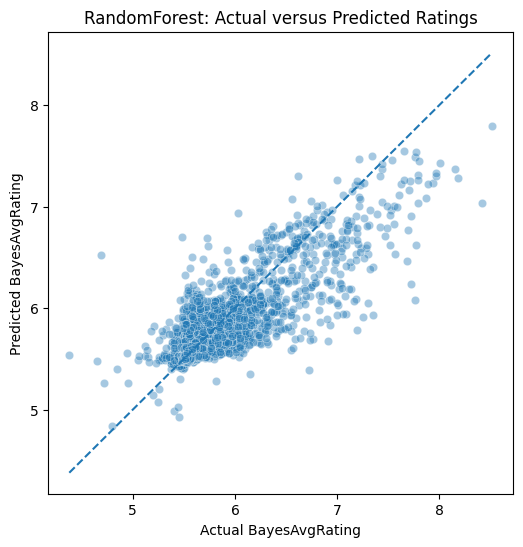

In [12]:
plt.figure(figsize=(6, 6))

sns.scatterplot(x=y_test, y=rf_preds, alpha=0.4)

# Reference line ("perfect" predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual BayesAvgRating")
plt.ylabel("Predicted BayesAvgRating")
plt.title("RandomForest: Actual versus Predicted Ratings")
plt.show()

🙋‍♀️ **RandomForest: Actual vs Predicted**

- ✅ Most points cluster around the line → model is working
- ✅ Clear upward trend → model captures signal
- Predictions broadly follow the true rating distribution, which is itself tightly clustered
- ⚠️ The model shows a tendency to slightly compress extreme values, underestimating very high-rated games and overestimating lower-rated ones (prioritising minimising overall error rather than capturing rare extremes)

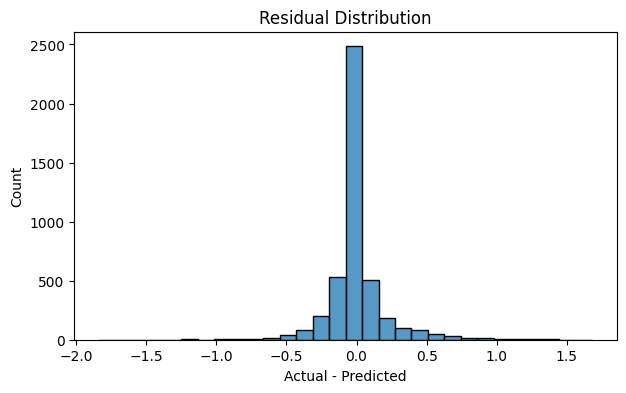

In [13]:
# Residuals plot
residuals = y_test - rf_preds

plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Actual - Predicted")
plt.show()

🙋‍♀️ **Residuals**

- ✅ Centred around 0 → no major bias
- ✅ Roughly symmetric → balanced errors
- ⚠️ Some big misses (±1 in tail) → some games are hard to predict

👉 **Model is generally well-calibrated but struggles on edge cases**

In [14]:
# Extract feature importance
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(20)

,feature,importance
14,Cat:Strategy,0.199030
8,NumAlternates,0.152009
5,LanguageEase,0.118041
9,NumExpansions,0.097756
0,YearPublished,0.069899
1,GameWeight,0.055866
16,Cat:Family,0.029539
4,ComAgeRec,0.021740
13,Cat:Thematic,0.020476
10,NumImplementations,0.012968


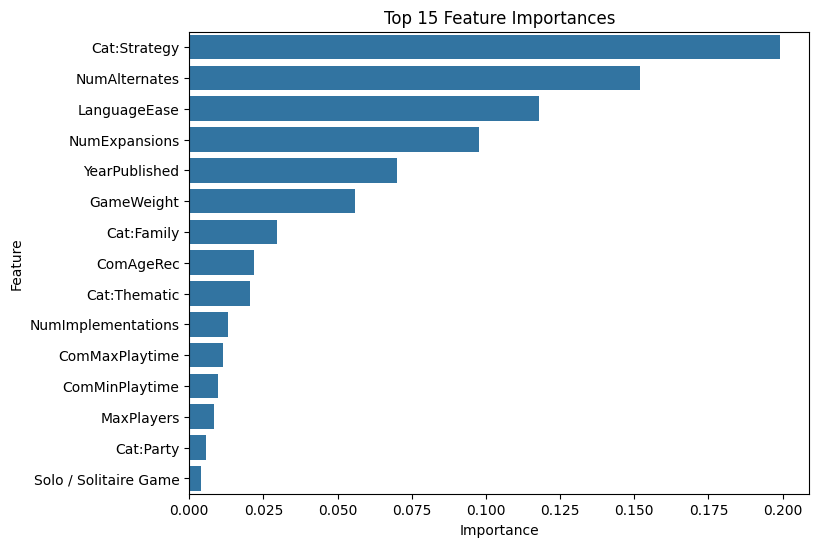

In [15]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

🙋‍♀️ **Feature importance**

- Being a **strategy game** is strongly associated with higher ratings (`Cat:Strategy`)
- **Popular / developed games** tend to rate higher (`NumAlternates`) → could be feedback loop again ⚠️
- **Easier-to-understand games** tend to have higher ratings, perhaps due to accessibility or fewer rules friction (`LanguageEase`)
- **More complex games** have slightly higher ratings (`GameWeight`)
- **Newer games** have slightly higher ratings ()`YearPublished`)

Low importance features include MinPlayers, MaxPlayers, and many game mechanics - similar to what was observed in the EDA.

## ⭐️ Summary: Baseline Models

#### Model Performance

The Random Forest model significantly outperforms the Dummy baseline:
- MAE reduced from ~0.24 → ~0.12
- R² ≈ 0.72

This indicates the model explains a substantial proportion of the variation in ratings.

👉 Despite weak individual relationships observed in EDA, the model is able to capture meaningful patterns through non-linear interactions across features.


#### Prediction Behaviour

Predictions broadly follow the true rating distribution, which is itself tightly clustered.

The model shows a slight tendency to compress extreme values:
- Very high-rated games are somewhat underestimated
- Lower-rated games are slightly overestimated

👉 This reflects a typical regression behaviour where the model prioritises minimising overall error, pulling predictions toward the mean.


#### Key Drivers of Rating

Feature importance highlights a small number of dominant signals:
- **Game category** (e.g. Strategy)
- **Game development indicators** (e.g. expansions, alternates)
- **Accessibility** (LanguageEase)
- **Structural attributes** (GameWeight, YearPublished)

These appear to be the strongest contributors to predicted rating.


#### What Doesn’t Matter Much

- Player count (min/max)
- Individual mechanics
- Many themes and subcategories

👉 These features show relatively low importance, reinforcing the earlier EDA finding that **no single intrinsic feature strongly determines rating**.

### 💡 Overall Takeaway
- Board game ratings are predictable, but not driven by simple, linear relationships.
- Instead, they emerge from interactions between multiple features.
- EDA alone suggested weak signal, but modelling reveals meaningful structure in the data.

👉 **Ratings aren’t driven by one thing - they’re the result of a combination of design, accessibility, and ecosystem signals.**